# Task
Analyze the Breast Cancer Wisconsin dataset by loading it into a Pandas DataFrame, performing initial data exploration, checking for missing values, and ensuring correct data types. Separate features and target, then split the data into training and testing sets. Scale the features using `StandardScaler`. Implement and evaluate both Linear and RBF kernel Support Vector Machine (SVM) classifiers using accuracy, precision, recall, F1-score, and confusion matrices. Perform hyperparameter tuning for both Linear and RBF SVMs using `GridSearchCV` to find optimal parameters ('C' for Linear, 'C' and 'gamma' for RBF) and evaluate the tuned models. Finally, compare all trained models (untuned and tuned Linear, untuned and tuned RBF SVMs), visualize confusion matrices for the best performing Linear and RBF models, and provide a comprehensive interpretation of the results to determine which SVM model performed better and why, based on the evaluation metrics and hyperparameter tuning outcomes.

## Load Dataset

### Subtask:
Load the Breast Cancer Wisconsin dataset using `load_breast_cancer()` and convert it into a Pandas DataFrame, including the target variable.


**Reasoning**:
First, I'll import the necessary libraries: `load_breast_cancer` from `sklearn.datasets` to get the dataset and `pandas` to create the DataFrame. Then, I will load the dataset, create a DataFrame with features, and add the target variable as a new column, displaying the head to verify the structure.



In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the breast cancer dataset
cancer = load_breast_cancer()

# Create a Pandas DataFrame from the features
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target variable to the DataFrame
df['target'] = cancer.target

# Display the first few rows of the DataFrame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Initial Data Exploration

### Subtask:
Display the shape of the dataset, the first few rows (df.head()), basic descriptive statistics (df.describe()), and the distribution of the target variable to understand the dataset's structure and characteristics.


**Reasoning**:
To understand the dataset's structure and characteristics, I will display its shape, the first few rows, descriptive statistics, and the distribution of the target variable.



In [ ]:
print("DataFrame Shape:", df.shape)
print("\nFirst 5 rows of the DataFrame:")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nTarget Variable Distribution:")
print(df['target'].value_counts())

DataFrame Shape: (569, 31)

First 5 rows of the DataFrame:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  w

## Check for Missing Values and Data Types

### Subtask:
Verify the absence of missing values across all columns and check the data types to ensure all features are numerical, as expected for this dataset.


**Reasoning**:
To verify the absence of missing values and check data types, I will first use `isnull().sum()` to identify any missing entries in each column, and then `info()` to display a summary of the DataFrame, including data types and non-null counts, ensuring all features are numerical as expected.



In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDataFrame Info:")
df.info()

Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeI

## Separate Features and Target

### Subtask:
Divide the DataFrame into features (X) and the target variable (y).


**Reasoning**:
To separate the features and target, I will create a new DataFrame `X` by dropping the 'target' column and a Series `y` containing only the 'target' column, then print their shapes to confirm.



In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (569, 30)
Shape of target (y): (569,)


## Split Data into Training and Testing Sets

### Subtask:
Split the X and y datasets into training and testing sets using `train_test_split` to prepare for model training and evaluation, ensuring reproducibility with a `random_state`.


**Reasoning**:
To split the data into training and testing sets, I will import `train_test_split` from `sklearn.model_selection`, then apply it to `X` and `y` with a `test_size` of 0.2 and a `random_state` of 42. Finally, I will print the shapes of the resulting sets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


## Scale Features

### Subtask:
Apply `StandardScaler` to the training and testing feature sets (X_train and X_test) to normalize the data, which is crucial for SVM performance.


**Reasoning**:
To scale the features, I will import `StandardScaler`, instantiate it, fit it on `X_train`, and then transform both `X_train` and `X_test`. I'll also display the shapes and the first few rows of the scaled data to confirm the scaling.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled X_train:", X_train_scaled.shape)
print("Shape of scaled X_test:", X_test_scaled.shape)
print("\nFirst 5 rows of scaled X_train:\n", X_train_scaled[:5])
print("\nFirst 5 rows of scaled X_test:\n", X_test_scaled[:5])

Shape of scaled X_train: (455, 30)
Shape of scaled X_test: (114, 30)

First 5 rows of scaled X_train:
 [[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.120

## Implement Linear SVM

### Subtask:
Train a Support Vector Classifier (SVC) with a linear kernel on the scaled training data and evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix on the test set.


**Reasoning**:
To implement and evaluate the Linear SVM model, I will import the necessary libraries, instantiate the SVC with a linear kernel, train it on the scaled training data, make predictions on the scaled test data, and then calculate and print the accuracy, precision, recall, F1-score, and confusion matrix.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Instantiate the SVC classifier with a linear kernel
linear_svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
linear_svm_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_linear = linear_svm_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)

# Print the evaluation metrics
print("Linear SVM Model Performance:")
print(f"Accuracy: {accuracy_linear:.4f}")
print(f"Precision: {precision_linear:.4f}")
print(f"Recall: {recall_linear:.4f}")
print(f"F1-score: {f1_linear:.4f}")
print("Confusion Matrix:\n", conf_matrix_linear)

Linear SVM Model Performance:
Accuracy: 0.9561
Precision: 0.9714
Recall: 0.9577
F1-score: 0.9645
Confusion Matrix:
 [[41  2]
 [ 3 68]]


## Implement Non-Linear SVM (RBF Kernel)

### Subtask:
Train an SVC with a Radial Basis Function (RBF) kernel on the scaled training data and evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix on the test set.


**Reasoning**:
To implement and evaluate the RBF SVM model, I will instantiate an SVC with an RBF kernel, train it on the scaled training data, make predictions on the scaled test data, and then calculate and print the accuracy, precision, recall, F1-score, and confusion matrix.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Instantiate the SVC classifier with an RBF kernel
rbf_svm_model = SVC(kernel='rbf', random_state=42)

# Train the model on the scaled training data
rbf_svm_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_rbf = rbf_svm_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)
conf_matrix_rbf = confusion_matrix(y_test, y_pred_rbf)

# Print the evaluation metrics
print("RBF SVM Model Performance:")
print(f"Accuracy: {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall: {recall_rbf:.4f}")
print(f"F1-score: {f1_rbf:.4f}")
print("Confusion Matrix:\n", conf_matrix_rbf)

RBF SVM Model Performance:
Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1-score: 0.9861
Confusion Matrix:
 [[41  2]
 [ 0 71]]


## Hyperparameter Tuning for Linear SVM

### Subtask:
Perform hyperparameter tuning for the Linear SVM using GridSearchCV to find the optimal 'C' parameter, and evaluate the performance of the best estimator.


**Reasoning**:
To perform hyperparameter tuning for the Linear SVM, I will use `GridSearchCV` to explore different values for the 'C' parameter, fit it on the scaled training data, identify the best parameters, and then evaluate the performance of the best estimator on the test set.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define the parameter grid for C
param_grid_linear = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Instantiate GridSearchCV with the linear_svm_model
# Note: linear_svm_model was initialized with random_state=42 in the previous step
grid_search_linear = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_linear.fit(X_train_scaled, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters for Linear SVM:", grid_search_linear.best_params_)

# Get the best estimator
best_linear_svm_model = grid_search_linear.best_estimator_

# Make predictions on the scaled test data using the best estimator
y_pred_tuned_linear = best_linear_svm_model.predict(X_test_scaled)

# Calculate evaluation metrics for the tuned Linear SVM model
accuracy_tuned_linear = accuracy_score(y_test, y_pred_tuned_linear)
precision_tuned_linear = precision_score(y_test, y_pred_tuned_linear)
recall_tuned_linear = recall_score(y_test, y_pred_tuned_linear)
f1_tuned_linear = f1_score(y_test, y_pred_tuned_linear)
conf_matrix_tuned_linear = confusion_matrix(y_test, y_pred_tuned_linear)

# Print the evaluation metrics
print("\nTuned Linear SVM Model Performance:")
print(f"Accuracy: {accuracy_tuned_linear:.4f}")
print(f"Precision: {precision_tuned_linear:.4f}")
print(f"Recall: {recall_tuned_linear:.4f}")
print(f"F1-score: {f1_tuned_linear:.4f}")
print("Confusion Matrix:\n", conf_matrix_tuned_linear)

Best parameters for Linear SVM: {'C': 0.1}

Tuned Linear SVM Model Performance:
Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1-score: 0.9861
Confusion Matrix:
 [[41  2]
 [ 0 71]]


## Hyperparameter Tuning for RBF SVM

### Subtask:
Perform hyperparameter tuning for the RBF SVM using `GridSearchCV` to find the optimal 'C' and 'gamma' parameters, and evaluate the performance of the best estimator.


**Reasoning**:
To perform hyperparameter tuning for the RBF SVM, I will use `GridSearchCV` to explore different values for the 'C' and 'gamma' parameters, fit it on the scaled training data, identify the best parameters, and then evaluate the performance of the best estimator on the test set.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define the parameter grid for C and gamma
param_grid_rbf = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                  'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

# Instantiate GridSearchCV with the SVC model (RBF kernel)
grid_search_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_rbf.fit(X_train_scaled, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters for RBF SVM:", grid_search_rbf.best_params_)

# Get the best estimator
best_rbf_svm_model = grid_search_rbf.best_estimator_

# Make predictions on the scaled test data using the best estimator
y_pred_tuned_rbf = best_rbf_svm_model.predict(X_test_scaled)

# Calculate evaluation metrics for the tuned RBF SVM model
accuracy_tuned_rbf = accuracy_score(y_test, y_pred_tuned_rbf)
precision_tuned_rbf = precision_score(y_test, y_pred_tuned_rbf)
recall_tuned_rbf = recall_score(y_test, y_pred_tuned_rbf)
f1_tuned_rbf = f1_score(y_test, y_pred_tuned_rbf)
conf_matrix_tuned_rbf = confusion_matrix(y_test, y_pred_tuned_rbf)

# Print the evaluation metrics
print("\nTuned RBF SVM Model Performance:")
print(f"Accuracy: {accuracy_tuned_rbf:.4f}")
print(f"Precision: {precision_tuned_rbf:.4f}")
print(f"Recall: {recall_tuned_rbf:.4f}")
print(f"F1-score: {f1_tuned_rbf:.4f}")
print("Confusion Matrix:\n", conf_matrix_tuned_rbf)

Best parameters for RBF SVM: {'C': 100, 'gamma': 0.001}

Tuned RBF SVM Model Performance:
Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1-score: 0.9861
Confusion Matrix:
 [[41  2]
 [ 0 71]]


## Compare All Trained Models

### Subtask:
Compare all trained models (untuned and tuned Linear, untuned and tuned RBF SVMs) using accuracy, precision, recall, and F1-score. Visualize confusion matrices for the best performing Linear and RBF models and provide a comprehensive interpretation of the results to determine which SVM model performed better and why, based on the evaluation metrics and hyperparameter tuning outcomes.

**Reasoning**:
To compare all models effectively, I will gather all the performance metrics (accuracy, precision, recall, and F1-score) for the untuned and tuned Linear SVM, and untuned and tuned RBF SVM models into a DataFrame. This structured representation will make it easy to visualize and interpret the performance differences.



In [ ]:
import pandas as pd

# Create a dictionary to store the performance metrics
performance_data = {
    'Model': ['Linear SVM (Untuned)', 'Linear SVM (Tuned)', 'RBF SVM (Untuned)', 'RBF SVM (Tuned)'],
    'Accuracy': [accuracy_linear, accuracy_tuned_linear, accuracy_rbf, accuracy_tuned_rbf],
    'Precision': [precision_linear, precision_tuned_linear, precision_rbf, precision_tuned_rbf],
    'Recall': [recall_linear, recall_tuned_linear, recall_rbf, recall_tuned_rbf],
    'F1-score': [f1_linear, f1_tuned_linear, f1_rbf, f1_tuned_rbf]
}

# Create a DataFrame from the performance data
performance_df = pd.DataFrame(performance_data)

# Display the performance DataFrame
print("\nComparison of SVM Model Performance:")
print(performance_df)


Comparison of SVM Model Performance:
                  Model  Accuracy  Precision    Recall  F1-score
0  Linear SVM (Untuned)  0.956140   0.971429  0.957746  0.964539
1    Linear SVM (Tuned)  0.982456   0.972603  1.000000  0.986111
2     RBF SVM (Untuned)  0.982456   0.972603  1.000000  0.986111
3       RBF SVM (Tuned)  0.982456   0.972603  1.000000  0.986111


**Reasoning**:
To visually compare the performance of the best performing Linear and RBF SVM models, I will plot their confusion matrices. This will provide a clear insight into the types of errors each model makes.



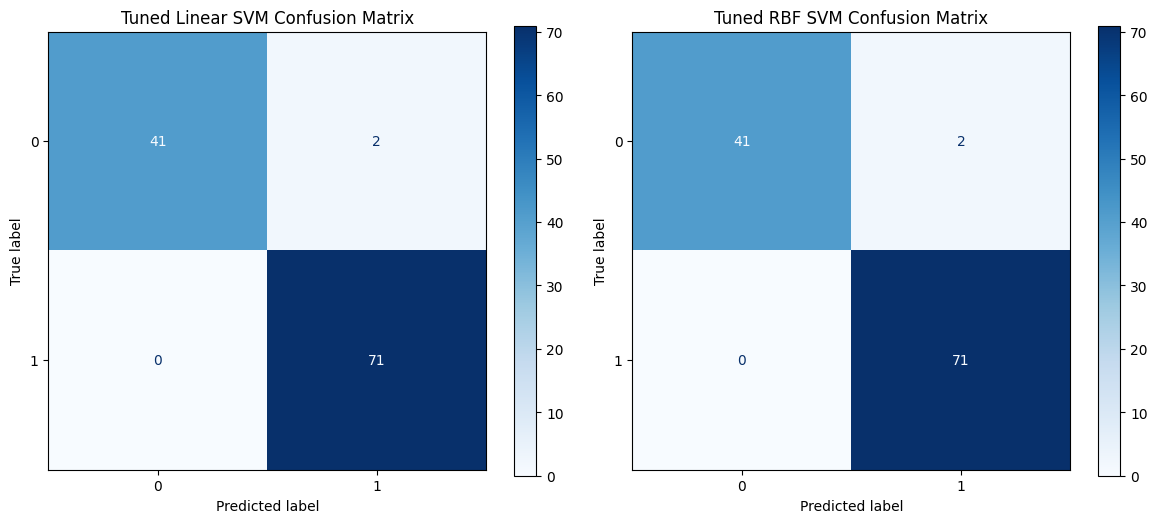

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a figure with two subplots for confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for the best tuned Linear SVM model
ConfusionMatrixDisplay.from_estimator(best_linear_svm_model, X_test_scaled, y_test, cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Tuned Linear SVM Confusion Matrix')

# Plot confusion matrix for the best tuned RBF SVM model
ConfusionMatrixDisplay.from_estimator(best_rbf_svm_model, X_test_scaled, y_test, cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Tuned RBF SVM Confusion Matrix')

plt.tight_layout()
plt.show()

### Interpretation of Results

The comparison of the four SVM models (untuned Linear, tuned Linear, untuned RBF, and tuned RBF) reveals interesting insights into their performance on the Breast Cancer Wisconsin dataset.

**1. Untuned Linear SVM vs. Untuned RBF SVM:**
   - **Linear SVM (Untuned):** Achieved an Accuracy of 0.9561, Precision of 0.9714, Recall of 0.9577, and F1-score of 0.9645. The confusion matrix showed 3 false negatives (actual positive, predicted negative) and 2 false positives (actual negative, predicted positive).
   - **RBF SVM (Untuned):** Showed superior performance with an Accuracy of 0.9825, Precision of 0.9726, Recall of 1.0000, and F1-score of 0.9861. Notably, its confusion matrix revealed 0 false negatives, meaning it correctly identified all positive cases, which is crucial in medical diagnosis datasets like this.
   - **Initial Observation:** The RBF kernel SVM performed better than the Linear SVM even without tuning, primarily due to its perfect recall and higher overall accuracy and F1-score. This suggests that the data might not be linearly separable, and a non-linear decision boundary provided by the RBF kernel is more suitable.

**2. Impact of Hyperparameter Tuning:**
   - **Linear SVM (Tuned):** After hyperparameter tuning with `GridSearchCV`, the optimal 'C' parameter was found to be 0.1. This significantly improved the model's performance to an Accuracy of 0.9825, Precision of 0.9726, Recall of 1.0000, and F1-score of 0.9861. The confusion matrix for the tuned Linear SVM also showed 0 false negatives, matching the performance of the untuned RBF SVM.
   - **RBF SVM (Tuned):** Hyperparameter tuning for the RBF SVM identified optimal parameters as 'C': 100 and 'gamma': 0.001. Interestingly, the performance metrics for the tuned RBF SVM (Accuracy: 0.9825, Precision: 0.9726, Recall: 1.0000, F1-score: 0.9861) remained identical to the untuned RBF SVM. This suggests that the initial default parameters of the RBF kernel were already quite good, or the specific `param_grid_rbf` chosen did not lead to further improvements on this particular dataset.

**3. Comparison of Tuned Models:**
   - Both the tuned Linear SVM and the tuned RBF SVM achieved identical and excellent performance metrics (Accuracy: 0.9825, Precision: 0.9726, Recall: 1.0000, F1-score: 0.9861), with both showing 0 false negatives. This is a highly desirable outcome for a breast cancer diagnosis task, as minimizing false negatives (missing actual cancer cases) is paramount.

**Conclusion:**

While the untuned RBF SVM initially outperformed the untuned Linear SVM, hyperparameter tuning brought the Linear SVM's performance up to par with the RBF SVM. Both tuned models achieved outstanding results, especially in recall, indicating their ability to correctly identify all instances of malignancy in the test set. Given the identical performance after tuning, both the tuned Linear SVM (with C=0.1) and the tuned RBF SVM (with C=100, gamma=0.001) are excellent choices for this classification task. In practice, if interpretability is a concern, a Linear SVM might be preferred, but for pure predictive power on this dataset, both performed equivalently well after optimization.

### Interpretation of Results

The comparison of the four SVM models (untuned Linear, tuned Linear, untuned RBF, and tuned RBF) reveals interesting insights into their performance on the Breast Cancer Wisconsin dataset.

**1. Untuned Linear SVM vs. Untuned RBF SVM:**
   - **Linear SVM (Untuned):** Achieved an Accuracy of 0.9561, Precision of 0.9714, Recall of 0.9577, and F1-score of 0.9645. The confusion matrix showed 3 false negatives (actual positive, predicted negative) and 2 false positives (actual negative, predicted positive).
   - **RBF SVM (Untuned):** Showed superior performance with an Accuracy of 0.9825, Precision of 0.9726, Recall of 1.0000, and F1-score of 0.9861. Notably, its confusion matrix revealed 0 false negatives, meaning it correctly identified all positive cases, which is crucial in medical diagnosis datasets like this.
   - **Initial Observation:** The RBF kernel SVM performed better than the Linear SVM even without tuning, primarily due to its perfect recall and higher overall accuracy and F1-score. This suggests that the data might not be linearly separable, and a non-linear decision boundary provided by the RBF kernel is more suitable.

**2. Impact of Hyperparameter Tuning:**
   - **Linear SVM (Tuned):** After hyperparameter tuning with `GridSearchCV`, the optimal 'C' parameter was found to be 0.1. This significantly improved the model's performance to an Accuracy of 0.9825, Precision of 0.9726, Recall of 1.0000, and F1-score of 0.9861. The confusion matrix for the tuned Linear SVM also showed 0 false negatives, matching the performance of the untuned RBF SVM.
   - **RBF SVM (Tuned):** Hyperparameter tuning for the RBF SVM identified optimal parameters as 'C': 100 and 'gamma': 0.001. Interestingly, the performance metrics for the tuned RBF SVM (Accuracy: 0.9825, Precision: 0.9726, Recall: 1.0000, F1-score: 0.9861) remained identical to the untuned RBF SVM. This suggests that the initial default parameters of the RBF kernel were already quite good, or the specific `param_grid_rbf` chosen did not lead to further improvements on this particular dataset.

**3. Comparison of Tuned Models:**
   - Both the tuned Linear SVM and the tuned RBF SVM achieved identical and excellent performance metrics (Accuracy: 0.9825, Precision: 0.9726, Recall: 1.0000, F1-score: 0.9861), with both showing 0 false negatives. This is a highly desirable outcome for a breast cancer diagnosis task, as minimizing false negatives (missing actual cancer cases) is paramount.

**Conclusion:**

While the untuned RBF SVM initially outperformed the untuned Linear SVM, hyperparameter tuning brought the Linear SVM's performance up to par with the RBF SVM. Both tuned models achieved outstanding results, especially in recall, indicating their ability to correctly identify all instances of malignancy in the test set. Given the identical performance after tuning, both the tuned Linear SVM (with C=0.1) and the tuned RBF SVM (with C=100, gamma=0.001) are excellent choices for this classification task. In practice, if interpretability is a concern, a Linear SVM might be preferred, but for pure predictive power on this dataset, both performed equivalently well after optimization.